In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt 

In [70]:
img_path='../data/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg'

In [71]:
from tensorflow.keras.applications.densenet import preprocess_input

In [72]:
img= tf.keras.preprocessing.image.load_img(
    img_path, 
    target_size=(224, 224)
)

img_array= tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)
img_array= preprocess_input(img_array)

In [73]:
from tensorflow.keras.models import load_model

In [74]:
model= load_model("../model/densenet_freeze.h5")

In [75]:
prediction=model.predict(img_array)
print("prediction probab: ", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 919ms/step
prediction probab:  0.9999793


In [76]:
for layer in model.layers[::-1]:
    if 'conv' in layer.name:
        print(layer.name)
        break

conv5_block16_concat


In [77]:
grad_model=tf.keras.models.Model(
    [model.inputs],
    [
        model.get_layer("conv5_block16_concat").output,
        model.output
    ]
)

In [78]:
with tf.GradientTape() as tape:
    conv_outputs, predictions= grad_model(img_array)
    loss=predictions[:,0]

/opt/anaconda3/envs/pneumonia/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [79]:
grads=tape.gradient(loss, conv_outputs)

In [80]:
pooled_grads= tf.reduce_mean(grads, axis=(0,1,2))

In [81]:
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)

heatmap /= np.max(heatmap)

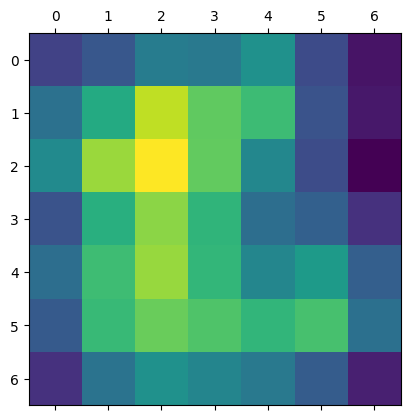

In [82]:
plt.matshow(heatmap)
plt.show()

In [83]:
img=cv2.imread(img_path)
img=cv2.resize(img, (224, 224))

In [84]:
heatmap=np.uint8(255*heatmap)

In [85]:
heatmap=cv2.resize(
    heatmap,
    (224,224)
)

In [86]:
heatmap=cv2.applyColorMap(
    heatmap, 
    cv2.COLORMAP_JET
)

In [87]:
img=tf.keras.preprocessing.image.img_to_array(img)
img=np.uint8(img)
print(type(img))

<class 'numpy.ndarray'>


In [88]:
superimposed_img=cv2.addWeighted(
    img ,
    0.6,
    heatmap,
    0.4,
    0
)

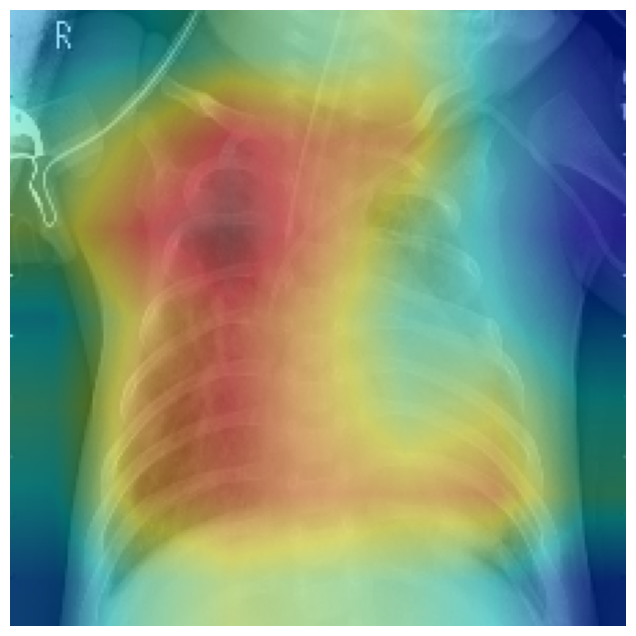

In [89]:
plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(
    superimposed_img,
    cv2.COLOR_BGR2RGB
))

plt.axis("off")

plt.show()